TensorFlow GPU enabled: 1 device(s)
Using MIT-BIH dataset path: /kaggle/input/datasets/mondejar/mitbih-database

  LOADING DATA — Patient-wise split, 3-class (Normal/Atrial/Other)

  Loading TRAIN patients ...


100%|██████████| 27/27 [01:44<00:00,  3.87s/it]



  Loading TEST patients ...


100%|██████████| 9/9 [00:34<00:00,  3.88s/it]



  Total train beats : 60925
  Total test  beats : 20297

  Classes     : [np.str_('Atrial'), np.str_('Normal'), np.str_('Other')]
  Train dist  : {np.str_('Atrial'): np.int64(887), np.str_('Normal'): np.int64(55463), np.str_('Other'): np.int64(4575)}
  Test  dist  : {np.str_('Atrial'): np.int64(1769), np.str_('Normal'): np.int64(16439), np.str_('Other'): np.int64(2089)}

  Building RR sequences (10-beat windows per patient) ...
  Sequence shape — train: (60925, 10, 3), test: (20297, 10, 3)

  PHASE 1 — RAW + Multi-Input BiLSTM Classifier

  Applying SMOTE on RAW data ...
  Train after SMOTE (RAW): 166389
  Class dist (RAW): {np.int64(0): np.int64(55463), np.int64(1): np.int64(55463), np.int64(2): np.int64(55463)}

  RAW classifier summary:


...

100%|██████████| 27/27 [2:26:03<00:00, 324.59s/it]



  STL-denoising TEST patients (record-level) ...


100%|██████████| 9/9 [48:44<00:00, 324.94s/it]


  STL train beats: 60925
  STL test  beats: 20297
  STL train shape: wave=(60925, 180, 1), feat=(60925, 29), seq=(60925, 10, 3)
  STL test  shape: wave=(20297, 180, 1), feat=(20297, 29), seq=(20297, 10, 3)

  Applying SMOTE on STL-denoised data ...
  Train after SMOTE: 166389
  Class dist: {np.int64(0): np.int64(55463), np.int64(1): np.int64(55463), np.int64(2): np.int64(55463)}

  Classifier summary:


    Model: "RAW_BiLSTM"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wave_input          │ (None, 180, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 180, 128)  │     33,792 │ wave_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 128)  │        256 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_input          │ (None, 29)        │         

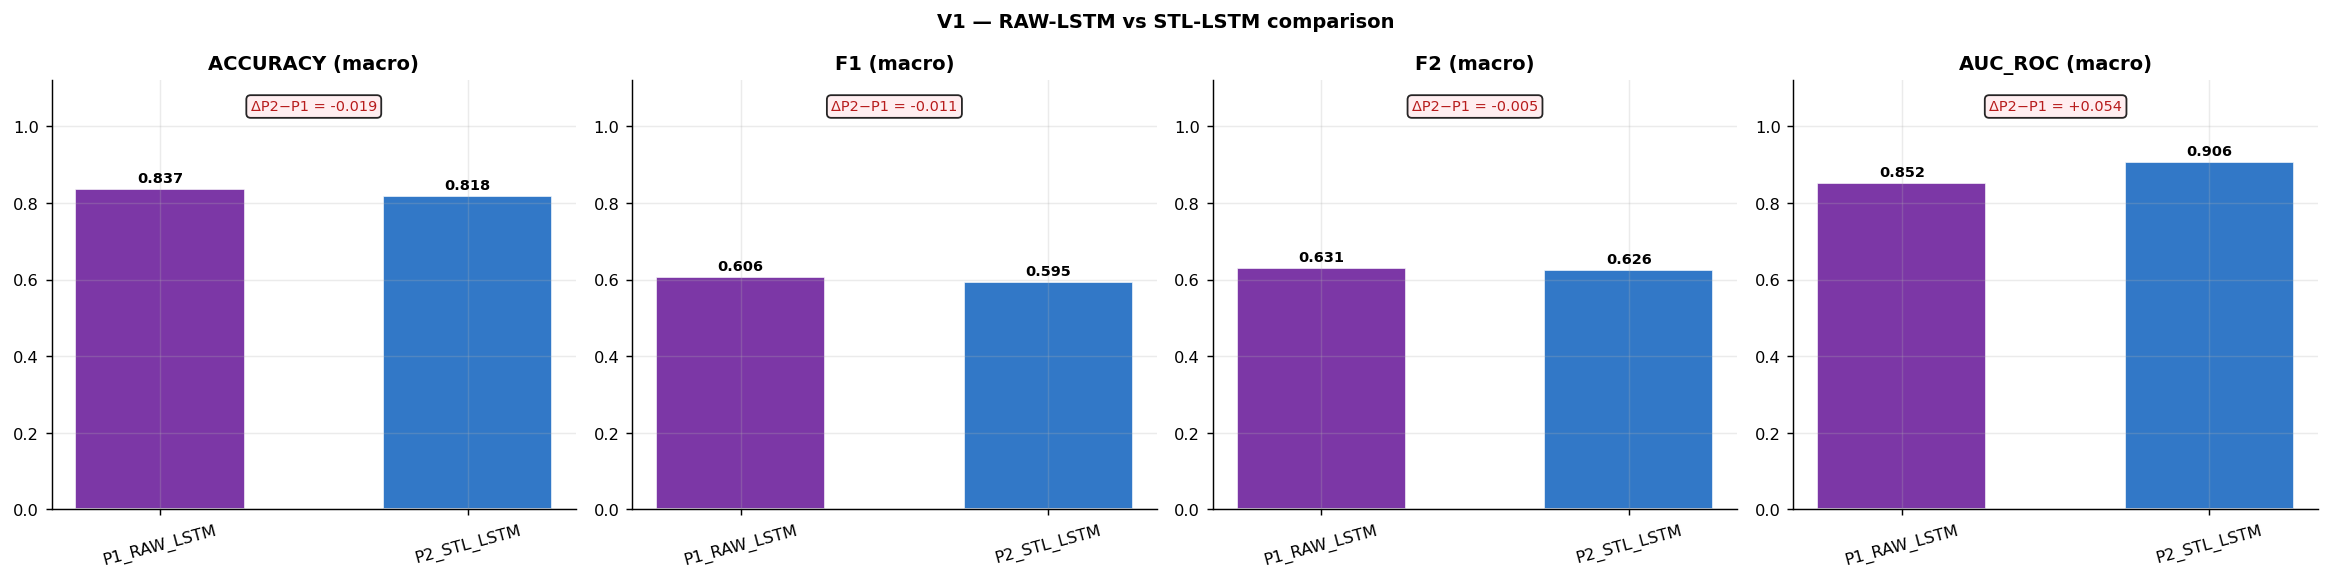

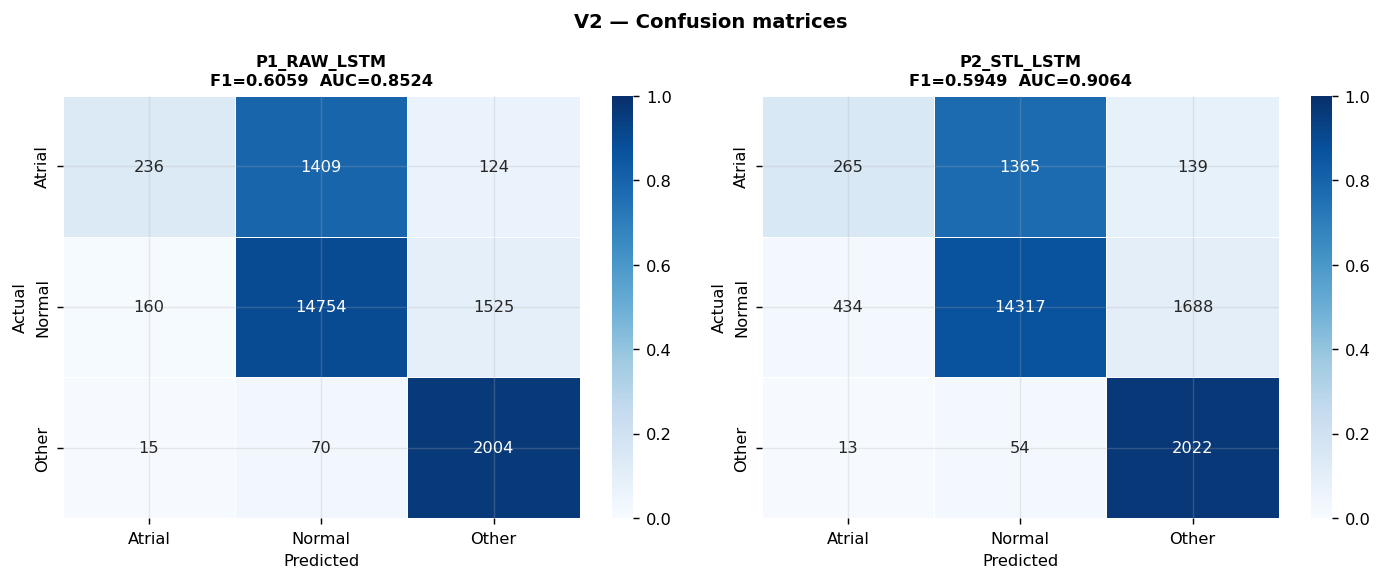

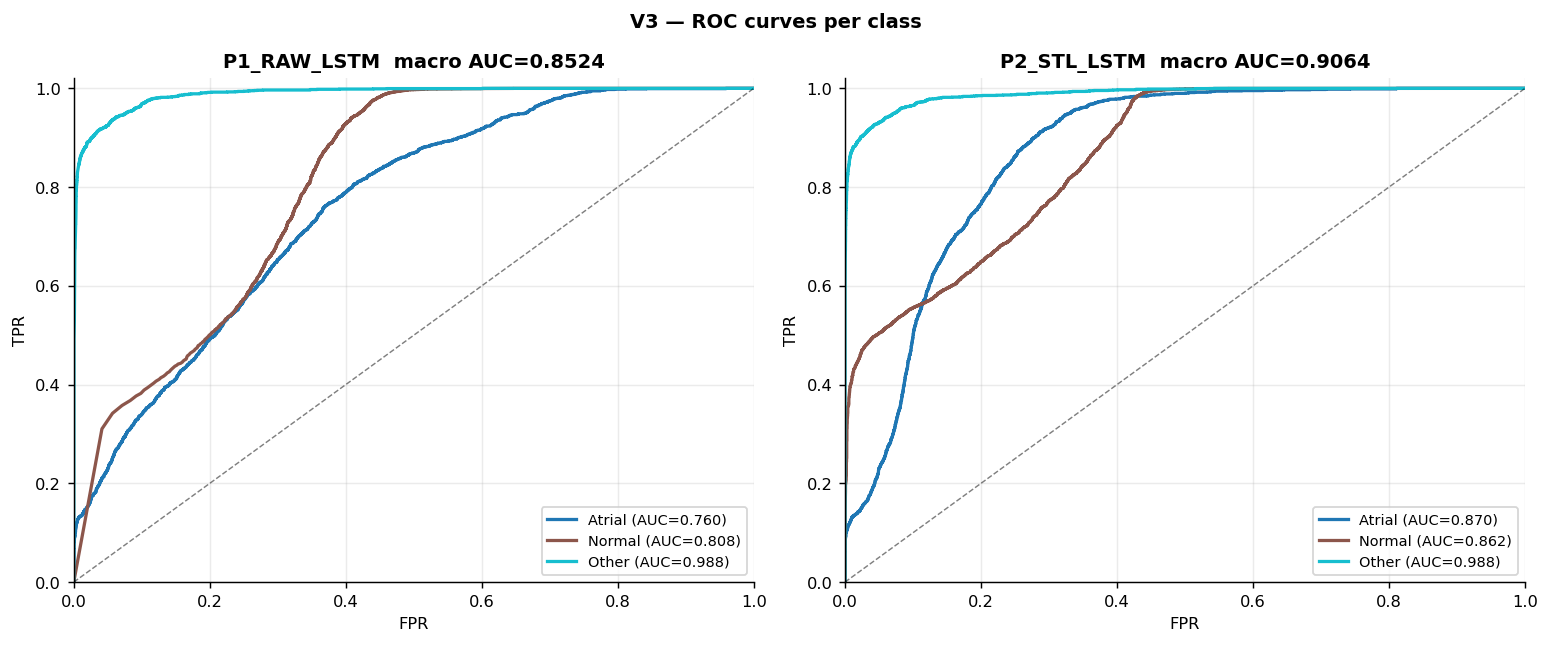

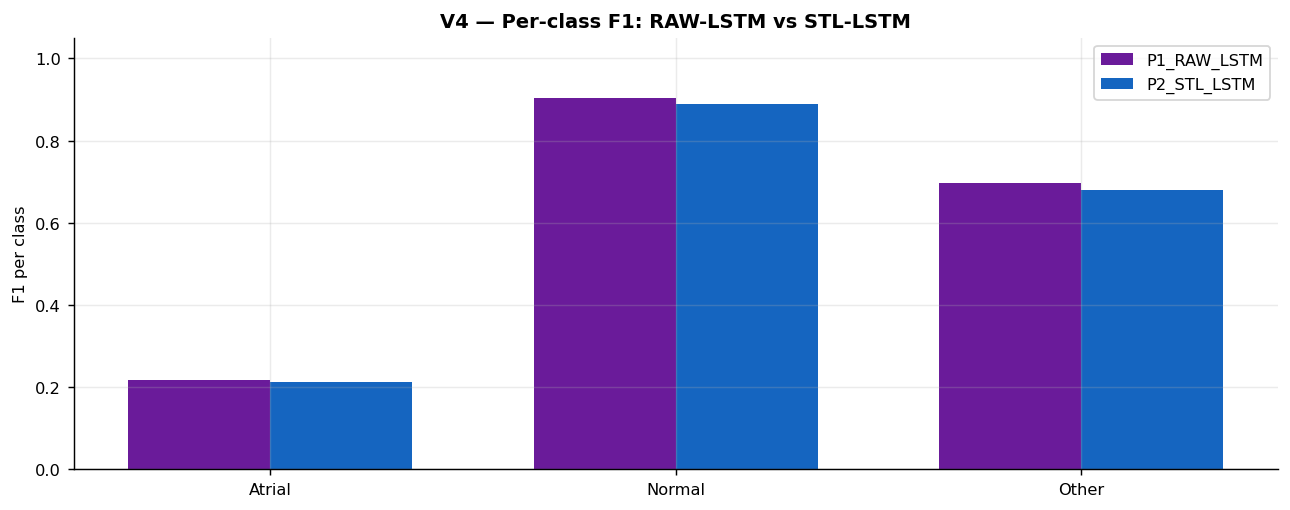

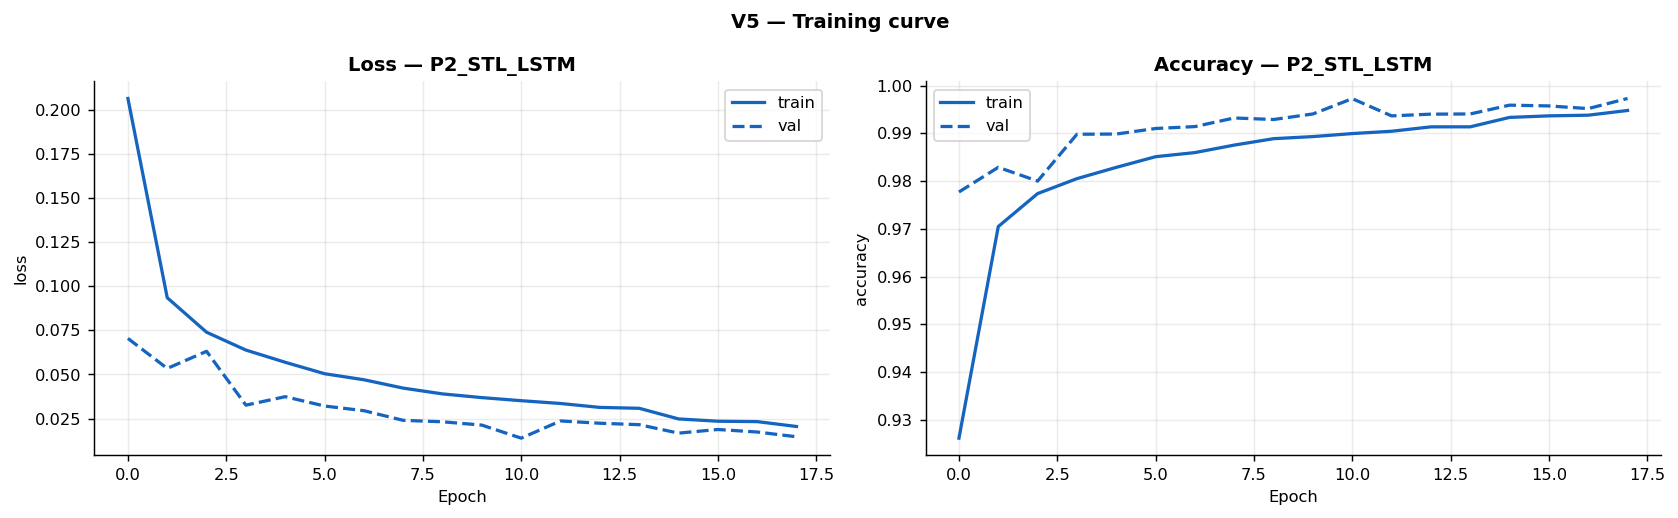

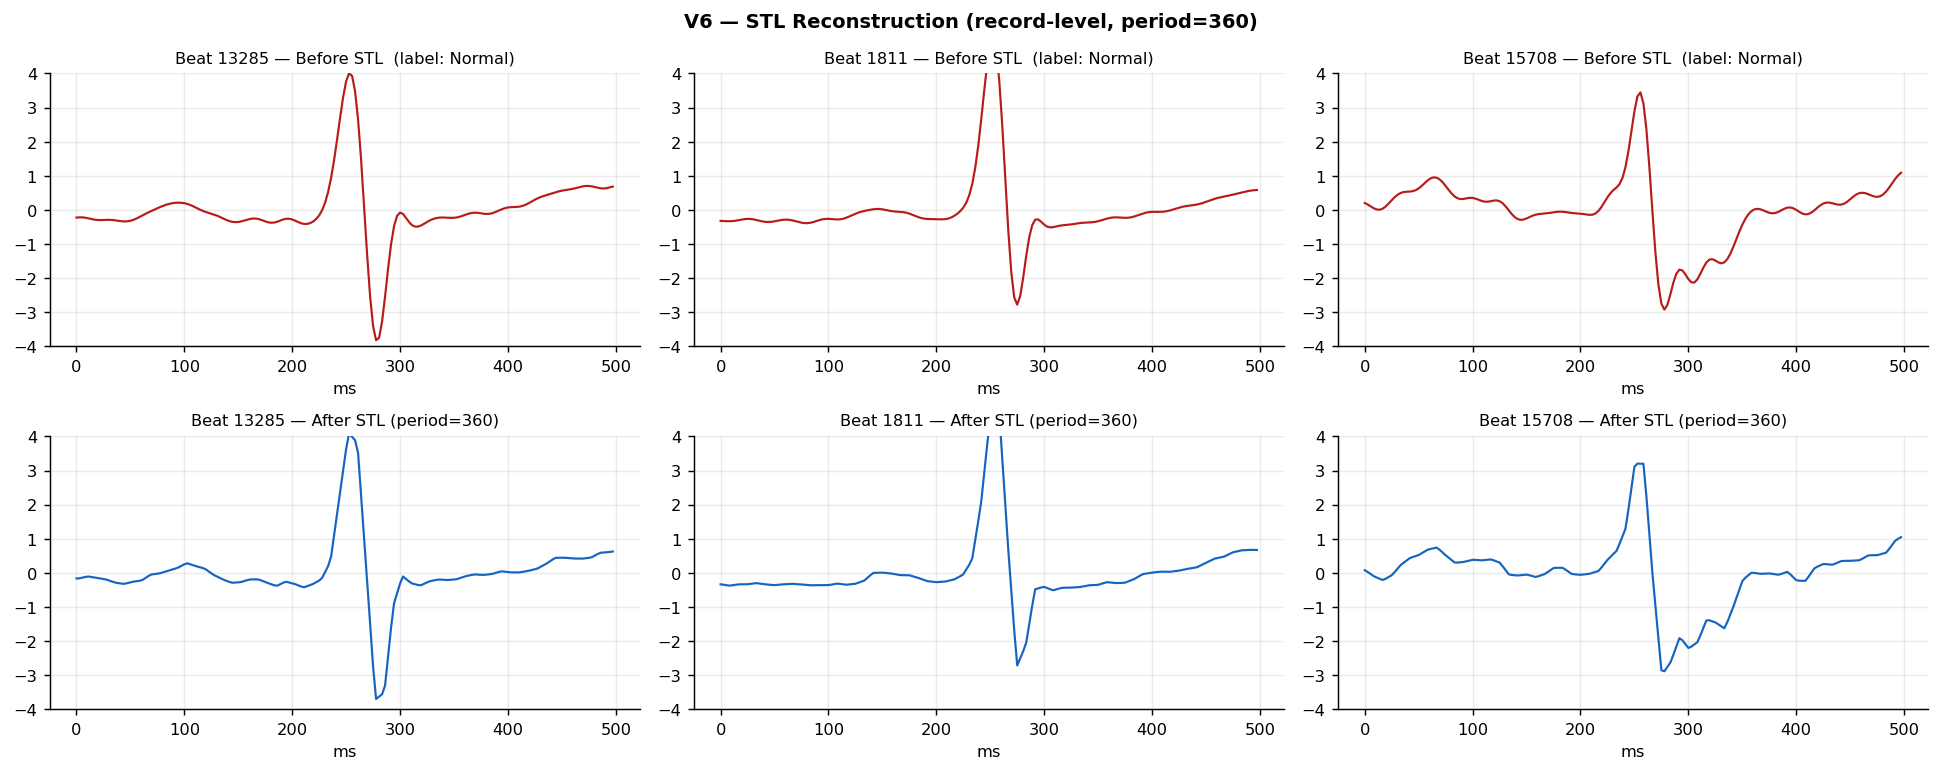

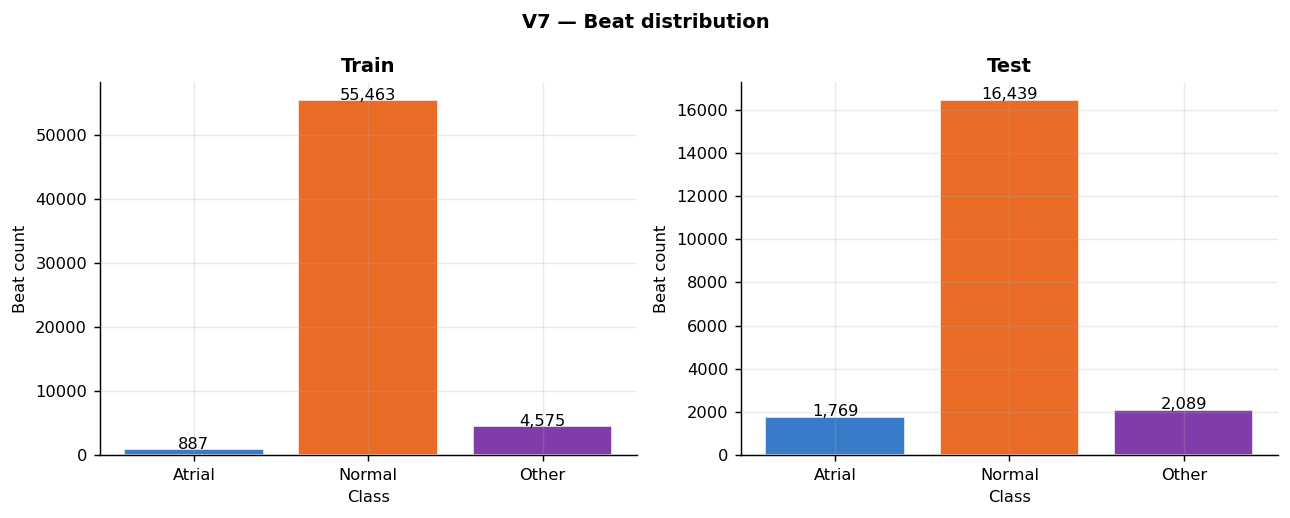


  Classification Report — P1_RAW_LSTM
              precision    recall  f1-score   support

      Atrial       0.57      0.13      0.22      1769
      Normal       0.91      0.90      0.90     16439
       Other       0.55      0.96      0.70      2089

    accuracy                           0.84     20297
   macro avg       0.68      0.66      0.61     20297
weighted avg       0.84      0.84      0.82     20297


  Classification Report — P2_STL_LSTM
              precision    recall  f1-score   support

      Atrial       0.37      0.15      0.21      1769
      Normal       0.91      0.87      0.89     16439
       Other       0.53      0.97      0.68      2089

    accuracy                           0.82     20297
   macro avg       0.60      0.66      0.59     20297
weighted avg       0.82      0.82      0.81     20297


  BEST PHASE : P1_RAW_LSTM
  Accuracy   = 0.8373
  F1 macro   = 0.6059
  F2 macro   = 0.6306
  AUC-ROC    = 0.8524

  Hybrid gain (STL-LSTM vs Pure STL):
    Δ

In [2]:
# =============================================================================
#  ECG ARRHYTHMIA CLASSIFICATION — RAW vs STL (Record-level) + LSTM
#  3-CLASS VERSION: Normal / Atrial / Other
#
#  KIẾN TRÚC TỔNG QUAN:
#    Input  : RR-interval features per beat  (RR, BPM, RR_z) + raw beat waveform
#    Phase 1: RAW + Multi-input BiLSTM classifier (baseline)
#             → dùng waveform raw (đã baseline+bandpass), RR-seq, handcrafted feats
#             → tại test: tính log-likelihood của RR-seq dưới mỗi class-model
#                        → predict class có likelihood cao nhất
#             (đây là baseline trực tiếp để so sánh với STL-denoised)
#
#    Phase 2: STL-denoised (record-level) → Multi-input BiLSTM classifier
#             → chạy STL trên tín hiệu dài theo từng record
#             → sau đó mới cắt beat 180 mẫu quanh R-peak
#                (các thành phần không tự-tương-quan = nhiễu, bị model loại bỏ)
#             → Đưa STL-denoised waveform vào BiLSTM classifier
#             → Có thể so sánh trực tiếp với LSTM-DAE codebase #1
#
#  TẠI SAO STL (record-level) CHO PIPELINE NÀY?
#    - STL cần chuỗi đủ dài để seasonal/trend decomposition có ý nghĩa
#    - Phần residual (signal − fitted) chính là nhiễu trắng (white noise)
#    - → Fitted values = denoised version
#    - So sánh công bằng: cùng classifier, chỉ khác bước denoising (RAW vs STL)
#    - Điều này phản ánh trực tiếp lợi ích của STL trong pipeline phân loại
#                        nhưng chậm hơn và yếu hơn với non-linearity
# =============================================================================

import os, warnings, gc, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps
from scipy.signal import medfilt, find_peaks
from scipy.stats import skew, kurtosis
import pywt
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, fbeta_score, accuracy_score,
                             precision_score, recall_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from tqdm import tqdm

# Time-series and deep-learning stack

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, callbacks, optimizers
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
    print(f"TensorFlow GPU enabled: {len(gpus)} device(s)")
else:
    print("TensorFlow GPU not found, using CPU")

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 9,
})

# =============================================================================
# CONFIG
# =============================================================================
EXTRACT_DIR = '/kaggle/input/datasets/mondejar/mitbih-database'
FS          = 360
WB, WA      = 90, 90
BEAT_LEN    = WB + WA       # 180

LABEL_MAP = {
    'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
    'A': 'Atrial', 'a': 'Atrial', 'J': 'Atrial', 'S': 'Atrial',
    'V': 'Other',  'E': 'Other',  'F': 'Other',
    '/': 'Other',  'f': 'Other',  'Q': 'Other',
}
CLASSES_ORDER = ['Normal', 'Atrial', 'Other']
N_CLASSES     = 3

TRAIN_PATIENTS = [100, 101, 103, 105, 106, 108, 109, 111, 112, 115,
                  116, 117, 118, 119, 121, 122, 123, 124, 200, 201,
                  202, 203, 205, 207, 208, 209, 215]
TEST_PATIENTS  = [220, 221, 222, 223, 228, 230, 231, 232, 233]

PALETTE = {
    'P1_RAW_LSTM' : '#6A1B9A',
    'P2_STL_LSTM': '#1565C0',
}

OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)


def resolve_mitbih_dir(default_dir):
    candidates = [
        default_dir,
        '/kaggle/input/mitbih-database',
        '/kaggle/input/mit-bih-arrhythmia-database',
        r'G:\My Drive\TKUD\MIT_BIH_Database',
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, '100.csv')) and os.path.exists(os.path.join(path, '100annotations.txt')):
            return path

    kaggle_root = '/kaggle/input'
    if os.path.exists(kaggle_root):
        for root, _, files in os.walk(kaggle_root):
            files = set(files)
            if '100.csv' in files and '100annotations.txt' in files:
                return root

    raise FileNotFoundError(
        "Cannot find MIT-BIH dataset. Attach the dataset on Kaggle and make sure the folder contains "
        "100.csv and 100annotations.txt. Current default EXTRACT_DIR: " + str(default_dir)
    )

EXTRACT_DIR = resolve_mitbih_dir(EXTRACT_DIR)
print(f"Using MIT-BIH dataset path: {EXTRACT_DIR}")

# Hyperparams
SEQ_LEN      = 10
LSTM_UNITS   = 64
LSTM_DROPOUT = 0.3
LSTM_EPOCHS  = 40
LSTM_BATCH   = 128
LSTM_LR      = 1e-3

# STL settings được định nghĩa ở Phase 2 (record-level denoising)


# =============================================================================
# 1. DATA LOADING
# =============================================================================
def load_record(rid):
    csv_path = os.path.join(EXTRACT_DIR, f'{rid}.csv')
    ann_path = os.path.join(EXTRACT_DIR, f'{rid}annotations.txt')

    sig_df = pd.read_csv(csv_path)
    sig_df.columns = [c.strip().strip("'\"") for c in sig_df.columns]
    col_map = {c.upper(): c for c in sig_df.columns}
    mlii_col = col_map.get('MLII')
    if mlii_col is None:
        num_cols = [c for c in sig_df.columns
                    if sig_df[c].dtype.kind in 'iuf' and 'sample' not in c.lower()]
        mlii_col = num_cols[0] if num_cols else None
    if mlii_col is None:
        raise ValueError(f"No MLII or numeric signal column found in {csv_path}. Columns: {list(sig_df.columns)}")
    mlii = sig_df[mlii_col].interpolate('linear').ffill().bfill().values.astype(float)

    beats_ann = []
    with open(ann_path, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3: continue
            try:
                sample_pos = int(parts[1])
                beat_type  = parts[2]
                beats_ann.append((sample_pos, beat_type))
            except ValueError:
                continue
    return mlii, beats_ann, len(mlii)


# =============================================================================
# 2. PREPROCESSING
# =============================================================================
def remove_baseline(sig):
    baseline = medfilt(sig, 71)
    baseline = medfilt(baseline, 215)
    return sig - baseline

def bandpass_filter(x, lo=0.5, hi=40.0, fs=FS, order=4):
    nyq = fs / 2
    b, a = sps.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sps.filtfilt(b, a, np.asarray(x, dtype=float))

def preprocess_signal(sig):
    return bandpass_filter(remove_baseline(sig.astype(float)))


# =============================================================================
# 3. RR / BPM / RR_z
# =============================================================================
def compute_rr_bpm_zscore(r_positions, fs=FS):
    n = len(r_positions)
    if n < 2:
        return np.zeros(n), np.zeros(n), np.zeros(n)
    rr_samples = np.diff(r_positions)
    rr_seconds = rr_samples / fs
    RR  = np.concatenate([[rr_seconds[0]], rr_seconds])
    BPM = 60.0 / np.clip(RR, 0.2, 3.0)
    mu, sd = RR.mean(), RR.std() + 1e-8
    RR_z = (RR - mu) / sd
    return RR, BPM, RR_z


# =============================================================================
# 4. HANDCRAFTED FEATURES
# =============================================================================
def feat_morph(b):
    b = np.asarray(b, dtype=float)
    return [
        b.mean(), b.std(), b.min(), b.max(),
        float(b.argmax()) / len(b),
        float(b.argmin()) / len(b),
        float(skew(b)), float(kurtosis(b)),
        float(np.trapz(np.abs(b))),
        float(np.sum(np.diff(b)**2)),
        float(np.max(np.abs(np.diff(b)))),
        float(np.sum(b > 0)) / len(b),
        float(np.percentile(b, 25)),
        float(np.percentile(b, 75)),
    ]

def feat_wavelet(b, wavelet='db1', level=3):
    coeffs = pywt.wavedec(np.asarray(b, dtype=float), wavelet, level=level)
    feats = []
    for c in coeffs:
        feats += [float(np.sum(c**2)), float(np.abs(c).max()), float(c.mean())]
    return feats

def extract_handcrafted(beat, rr, bpm, rr_z):
    return feat_morph(beat) + feat_wavelet(beat) + [rr, bpm, rr_z]

def sanitize(X):
    X = np.array(X, dtype=float)
    X = np.where(np.isinf(X), np.nan, X)
    df = pd.DataFrame(X)
    return df.interpolate('linear').ffill().bfill().fillna(0).values


# =============================================================================
# 5. BUILD DATASET (Patient-wise split)
# =============================================================================
print("\n" + "="*72)
print("  LOADING DATA — Patient-wise split, 3-class (Normal/Atrial/Other)")
print("="*72)

def build_per_patient_beats(rid):
    try:
        mlii, beats_ann, sig_len = load_record(rid)
    except FileNotFoundError:
        return []
    except Exception as e:
        print(f"  [WARN] {rid}: {e}")
        return []

    sig_clean = preprocess_signal(mlii)
    r_positions, labels = [], []
    for sample_pos, beat_type in beats_ann:
        if beat_type not in LABEL_MAP: continue
        if sample_pos - WB < 0 or sample_pos + WA >= sig_len: continue
        r_positions.append(sample_pos)
        labels.append(LABEL_MAP[beat_type])
    r_positions = np.array(r_positions)
    if len(r_positions) < 2: return []

    RR, BPM, RR_z = compute_rr_bpm_zscore(r_positions)
    out = []
    for i, (s, lab) in enumerate(zip(r_positions, labels)):
        beat = sig_clean[s - WB : s + WA]
        feat = extract_handcrafted(beat, RR[i], BPM[i], RR_z[i])
        out.append({
            'beat': beat.astype(np.float32),
            'rr': float(RR[i]), 'bpm': float(BPM[i]), 'rr_z': float(RR_z[i]),
            'feat': feat, 'label': lab, 'patient': rid,
        })
    return out

def build_dataset():
    train_beats, test_beats = [], []
    print("\n  Loading TRAIN patients ...")
    for rid in tqdm(TRAIN_PATIENTS):
        train_beats += build_per_patient_beats(rid)
    print("\n  Loading TEST patients ...")
    for rid in tqdm(TEST_PATIENTS):
        test_beats += build_per_patient_beats(rid)
    return train_beats, test_beats

train_beats, test_beats = build_dataset()
print(f"\n  Total train beats : {len(train_beats)}")
print(f"  Total test  beats : {len(test_beats)}")

if len(train_beats) == 0 or len(test_beats) == 0:
    raise RuntimeError(
        f"No beats were created. Check EXTRACT_DIR={EXTRACT_DIR}, available record files, and annotation format. "
        f"train_beats={len(train_beats)}, test_beats={len(test_beats)}"
    )


# =============================================================================
# 6. CONVERT TO ARRAYS
# =============================================================================
def beats_to_arrays(beats_list):
    W   = np.array([b['beat']  for b in beats_list], dtype=np.float32)[..., None]
    F   = np.array([b['feat']  for b in beats_list], dtype=np.float32)
    RR  = np.array([[b['rr'], b['bpm'], b['rr_z']] for b in beats_list],
                   dtype=np.float32)
    y   = np.array([b['label'] for b in beats_list])
    pid = np.array([b['patient'] for b in beats_list])
    return W, F, RR, y, pid

X_w_tr, X_f_tr, X_rr_tr, y_tr_raw, pid_tr = beats_to_arrays(train_beats)
X_w_te, X_f_te, X_rr_te, y_te_raw, pid_te = beats_to_arrays(test_beats)

le = LabelEncoder()
le.fit(CLASSES_ORDER)
y_tr_enc = le.transform(y_tr_raw)
y_te_enc = le.transform(y_te_raw)

print(f"\n  Classes     : {list(le.classes_)}")
print(f"  Train dist  : {dict(zip(*np.unique(y_tr_raw, return_counts=True)))}")
print(f"  Test  dist  : {dict(zip(*np.unique(y_te_raw, return_counts=True)))}")


# =============================================================================
# 7. RR SEQUENCE BUILDING (per patient)
# =============================================================================
def build_rr_sequences(X_rr, pid, seq_len=SEQ_LEN):
    N = len(X_rr)
    seqs = np.zeros((N, seq_len, 3), dtype=np.float32)
    for i in range(N):
        cur_pid = pid[i]
        start = max(0, i - seq_len + 1)
        candidate_idx = [j for j in range(start, i + 1) if pid[j] == cur_pid]
        seq = X_rr[candidate_idx]
        if len(seq) < seq_len:
            pad = np.repeat(seq[:1], seq_len - len(seq), axis=0)
            seq = np.vstack([pad, seq])
        seqs[i] = seq[-seq_len:]
    return seqs

print("\n  Building RR sequences (10-beat windows per patient) ...")
X_seq_tr = build_rr_sequences(X_rr_tr, pid_tr)
X_seq_te = build_rr_sequences(X_rr_te, pid_te)
print(f"  Sequence shape — train: {X_seq_tr.shape}, test: {X_seq_te.shape}")


# =============================================================================
# 8. NORMALIZATION
# =============================================================================
def zscore_waveform(W):
    mu = W.mean(axis=1, keepdims=True)
    sd = W.std(axis=1, keepdims=True) + 1e-8
    return (W - mu) / sd

X_w_tr_z = zscore_waveform(X_w_tr)
X_w_te_z = zscore_waveform(X_w_te)

sc_f = StandardScaler()
X_f_tr_s = sc_f.fit_transform(X_f_tr)
X_f_te_s = sc_f.transform(X_f_te)

sc_rr = StandardScaler()
N_tr, T_seq, C = X_seq_tr.shape
X_seq_tr_s = sc_rr.fit_transform(X_seq_tr.reshape(-1, C)).reshape(N_tr, T_seq, C)
X_seq_te_s = sc_rr.transform(X_seq_te.reshape(-1, C)).reshape(len(X_seq_te), T_seq, C)


# =============================================================================
# 9. PHASE 1 — RAW + Multi-Input BiLSTM Classifier
# =============================================================================
print("\n" + "="*72)
print("  PHASE 1 — RAW + Multi-Input BiLSTM Classifier")
print("="*72)

def apply_smote_multi(X_w, X_f, X_seq, y):
    Nw, T_w, _ = X_w.shape
    N_, T_s, C = X_seq.shape
    X_comb = np.hstack([X_w.reshape(Nw, T_w),
                        X_f,
                        X_seq.reshape(N_, T_s * C)])
    try:
        counts = np.bincount(y)
        min_c  = counts[counts > 0].min()
        k_nn   = max(1, min(5, min_c - 1))
        X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_comb, y)
    except Exception as e:
        print(f"  [SMOTE warn] {e} — skipping")
        return X_w, X_f, X_seq, y
    X_w_sm   = X_sm[:, :T_w].reshape(-1, T_w, 1)
    X_f_sm   = X_sm[:, T_w : T_w + X_f.shape[1]]
    X_seq_sm = X_sm[:, T_w + X_f.shape[1]:].reshape(-1, T_s, C)
    return X_w_sm, X_f_sm, X_seq_sm, y_sm

print("\n  Applying SMOTE on RAW data ...")
X_w_tr_raw_sm, X_f_tr_raw_sm, X_seq_tr_raw_sm, y_tr_raw_sm = apply_smote_multi(
    X_w_tr_z, X_f_tr_s, X_seq_tr_s, y_tr_enc)
print(f"  Train after SMOTE (RAW): {len(y_tr_raw_sm)}")
print(f"  Class dist (RAW): {dict(zip(*np.unique(y_tr_raw_sm, return_counts=True)))}")

class AttentionLayer(layers.Layer):
    def __init__(self, units=64, **kw):
        super().__init__(**kw)
        self.units = units
    def build(self, input_shape):
        D = input_shape[-1]
        self.W = self.add_weight(shape=(D, self.units),
                                 initializer='glorot_uniform', name='W')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros', name='b')
        self.u = self.add_weight(shape=(self.units, 1),
                                 initializer='glorot_uniform', name='u')
    def call(self, x):
        uit = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        ait = tf.squeeze(tf.tensordot(uit, self.u, axes=1), -1)
        a   = tf.expand_dims(tf.nn.softmax(ait, axis=1), -1)
        return tf.reduce_sum(x * a, axis=1)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


def build_multi_input_classifier(beat_len, n_feat, seq_len, seq_chan, n_classes):
    inp_w = Input(shape=(beat_len, 1), name='wave_input')
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True,
                        dropout=LSTM_DROPOUT,
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))(inp_w)
    a = layers.LayerNormalization()(a)
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=LSTM_DROPOUT))(a)
    a = layers.LayerNormalization()(a)
    a = AttentionLayer(units=LSTM_UNITS)(a)

    inp_seq = Input(shape=(seq_len, seq_chan), name='rr_seq_input')
    b = layers.Bidirectional(
            layers.LSTM(32, return_sequences=True, dropout=LSTM_DROPOUT))(inp_seq)
    b = layers.Bidirectional(
            layers.LSTM(16, return_sequences=False, dropout=LSTM_DROPOUT))(b)

    inp_f = Input(shape=(n_feat,), name='feat_input')
    c = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp_f)
    c = layers.Dropout(LSTM_DROPOUT)(c)
    c = layers.Dense(32, activation='relu')(c)

    z = layers.Concatenate()([a, b, c])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(LSTM_DROPOUT)(z)
    z = layers.Dense(32, activation='relu')(z)
    out = layers.Dense(n_classes, activation='softmax')(z)

    model = Model(inputs=[inp_w, inp_seq, inp_f], outputs=out,
                  name='RAW_BiLSTM')
    model.compile(optimizer=optimizers.Adam(LSTM_LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def evaluate_predictions(y_true, y_pred, y_proba, n_cls):
    m = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f2'       : fbeta_score(y_true, y_pred, average='macro', beta=2, zero_division=0),
    }
    try:
        yt_bin = label_binarize(y_true, classes=np.arange(n_cls))
        valid  = yt_bin.sum(axis=0) > 0
        m['auc_roc'] = (roc_auc_score(yt_bin[:, valid], y_proba[:, valid],
                                       multi_class='ovr', average='macro')
                        if valid.sum() > 1 else float('nan'))
    except Exception:
        m['auc_roc'] = float('nan')
    return m


tf.keras.backend.clear_session()
classifier_p1 = build_multi_input_classifier(
    beat_len=BEAT_LEN, n_feat=X_f_tr_raw_sm.shape[1],
    seq_len=SEQ_LEN, seq_chan=3, n_classes=N_CLASSES,
)
print("\n  RAW classifier summary:")
classifier_p1.summary(print_fn=lambda t: print('    ' + t))

cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_raw_sm)
class_weight_dict = {i: w for i, w in enumerate(cw)}

cb1 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

print(f"\n  Training Phase 1 ({LSTM_EPOCHS} epochs max) ...")
hist_p1 = classifier_p1.fit(
    [X_w_tr_raw_sm, X_seq_tr_raw_sm, X_f_tr_raw_sm],
    to_categorical(y_tr_raw_sm, N_CLASSES),
    validation_split=0.15, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=cb1, class_weight=class_weight_dict, verbose=2)

yprob_p1 = classifier_p1.predict(
    [X_w_te_z, X_seq_te_s, X_f_te_s],
    batch_size=LSTM_BATCH, verbose=0)
yp_p1 = yprob_p1.argmax(axis=1)

m_p1 = evaluate_predictions(y_te_enc, yp_p1, yprob_p1, N_CLASSES)
m_p1.update({'phase': 'P1_RAW_LSTM', 'y_true': y_te_enc,
             'y_pred': yp_p1, 'y_proba': yprob_p1, 'history': hist_p1.history})
print(f"\n  [P1_RAW_LSTM]  acc={m_p1['accuracy']:.4f}  F1={m_p1['f1']:.4f}  "
      f"F2={m_p1['f2']:.4f}  AUC={m_p1['auc_roc']:.4f}")

classifier_p1.save(f'{OUT_DIR}/p1_raw_lstm_classifier.keras')

# =============================================================================
# 9.5 STL DECOMPOSER (used for denoising in Phase 2)
# =============================================================================
class STLDecomposer:
    def __init__(self, period=30, seasonal_window=11, trend_window=None, lowpass_window=None,
                 inner_iter=2, outer_iter=1, degree=1):
        if period < 2:
            raise ValueError("period must be >= 2")
        self.period = int(period)
        self.seasonal_window = self._make_odd(max(3, int(seasonal_window)))
        if trend_window is None:
            tw = int(np.ceil(1.5 * self.period / (1 - 1.5 / self.seasonal_window)))
            self.trend_window = self._make_odd(max(3, tw))
        else:
            self.trend_window = self._make_odd(max(3, int(trend_window)))
        self.lowpass_window = self._make_odd(max(3, self.period if lowpass_window is None else int(lowpass_window)))
        self.inner_iter = max(1, int(inner_iter))
        self.outer_iter = max(0, int(outer_iter))
        self.degree = 1 if degree != 0 else 0

    @staticmethod
    def _make_odd(v):
        return v if v % 2 == 1 else v + 1

    @staticmethod
    def _tricube(u):
        au = np.abs(u)
        w = np.zeros_like(au)
        m = au < 1
        w[m] = (1 - au[m] ** 3) ** 3
        return w

    @staticmethod
    def _bisquare(u):
        au = np.abs(u)
        w = np.zeros_like(au)
        m = au < 1
        w[m] = (1 - au[m] ** 2) ** 2
        return w

    def _loess(self, y, window, robust_weights=None):
        y = np.asarray(y, dtype=float)
        n = len(y)
        x = np.arange(n, dtype=float)
        fit = np.empty(n, dtype=float)
        half = window // 2
        if robust_weights is None:
            robust_weights = np.ones(n, dtype=float)
        for i in range(n):
            l = max(0, i - half)
            r = min(n - 1, i + half)
            if r - l + 1 < window:
                l = max(0, r - window + 1)
                r = min(n - 1, l + window - 1)
            idx = np.arange(l, r + 1)
            xi = x[idx]
            yi = y[idx]
            d = np.max(np.abs(xi - x[i]))
            if d == 0:
                fit[i] = y[i]
                continue
            w = self._tricube((xi - x[i]) / d) * robust_weights[idx]
            if np.all(w <= 1e-12):
                fit[i] = y[i]
                continue
            if self.degree == 0:
                fit[i] = np.sum(w * yi) / np.sum(w)
            else:
                X = np.column_stack([np.ones_like(xi), xi - x[i]])
                WX = X * w[:, None]
                beta, *_ = np.linalg.lstsq(WX.T @ X, WX.T @ yi, rcond=None)
                fit[i] = beta[0]
        return fit

    def _moving_average(self, y, w):
        y = np.asarray(y, dtype=float)
        n = len(y)
        half = w // 2
        out = np.empty(n, dtype=float)
        for i in range(n):
            l = max(0, i - half)
            r = min(n, i + half + 1)
            out[i] = y[l:r].mean()
        return out

    def _smooth_cycle_subseries(self, detrended, robust_weights):
        n = len(detrended)
        seasonal = np.zeros(n, dtype=float)
        for phase in range(self.period):
            idx = np.arange(phase, n, self.period)
            if len(idx) > 0:
                seasonal[idx] = self._loess(detrended[idx], self.seasonal_window, robust_weights[idx])
        return seasonal

    def _lowpass_on_seasonal(self, seasonal):
        lp = self._moving_average(seasonal, self.period)
        lp = self._moving_average(lp, self.period)
        lp = self._moving_average(lp, 3)
        return self._loess(lp, self.lowpass_window)

    def fit_transform(self, ts):
        y = np.asarray(ts, dtype=float).reshape(-1)
        n = len(y)
        if n < 2 * self.period:
            return np.zeros(n, dtype=np.float32), np.zeros(n, dtype=np.float32), y.astype(np.float32)
        trend = self._loess(y, self.trend_window)
        seasonal = np.zeros(n, dtype=float)
        robust_weights = np.ones(n, dtype=float)
        for _ in range(self.outer_iter + 1):
            for _ in range(self.inner_iter):
                detrended = y - trend
                seasonal_raw = self._smooth_cycle_subseries(detrended, robust_weights)
                seasonal = seasonal_raw - self._lowpass_on_seasonal(seasonal_raw)
                trend = self._loess(y - seasonal, self.trend_window, robust_weights)
            residual = y - seasonal - trend
            mad = np.median(np.abs(residual))
            robust_weights = np.ones(n) if mad <= 1e-12 else self._bisquare(residual / (6.0 * mad))
        residual = y - seasonal - trend
        return seasonal.astype(np.float32), trend.astype(np.float32), residual.astype(np.float32)

# =============================================================================
# 10. PHASE 2 — STL-DENOISED (record-level) → Multi-Input BiLSTM
# =============================================================================
print("\n" + "="*72)
print("  PHASE 2 — STL-denoised (record-level) → Multi-Input BiLSTM Classifier")
print("="*72)

STL_PERIOD = 360
STL_CHUNK_SECONDS = 45
STL_OVERLAP_SECONDS = 5
STL_DOWNSAMPLE_FACTOR = 3

# Kaggle-friendly cache location (persist during one notebook session)
STL_CACHE_DIR = '/kaggle/working/stl_cache'
os.makedirs(STL_CACHE_DIR, exist_ok=True)

stl_model = STLDecomposer(period=max(3, STL_PERIOD // STL_DOWNSAMPLE_FACTOR),
                          seasonal_window=13, inner_iter=2, outer_iter=1)

def _cache_path_for_record(rid):
    return os.path.join(STL_CACHE_DIR, f'record_{rid}_stl_ds{STL_DOWNSAMPLE_FACTOR}_p{STL_PERIOD}.npy')


def _downsample_signal(x, factor):
    if factor <= 1:
        return x
    # anti-alias then decimate
    y = sps.decimate(x, q=factor, ftype='fir', zero_phase=True)
    return np.asarray(y, dtype=float)


def _upsample_to_len(x_ds, target_len, factor):
    if factor <= 1:
        return x_ds[:target_len]
    xi = np.linspace(0, target_len - 1, num=len(x_ds))
    xo = np.arange(target_len)
    return np.interp(xo, xi, x_ds)


def stl_denoise_record(sig, stl_model, fs=FS,
                      chunk_seconds=45, overlap_seconds=5,
                      downsample_factor=3):
    sig = np.asarray(sig, dtype=float)
    n = len(sig)
    if n < 2 * STL_PERIOD:
        return sig.astype(np.float32)

    # Step 1: downsample for faster STL
    sig_ds = _downsample_signal(sig, downsample_factor)
    fs_ds = fs / downsample_factor

    chunk_len = int(fs_ds * chunk_seconds)
    overlap = int(fs_ds * overlap_seconds)
    min_len = max(2 * stl_model.period + 50, 200)
    chunk_len = max(chunk_len, min_len)

    out = np.zeros(len(sig_ds), dtype=float)
    wsum = np.zeros(len(sig_ds), dtype=float)
    step = max(1, chunk_len - overlap)

    # Step 2: chunk STL + overlap blending
    for left in range(0, len(sig_ds), step):
        right = min(len(sig_ds), left + chunk_len)
        chunk = sig_ds[left:right]
        if len(chunk) < 2 * stl_model.period:
            den = chunk
        else:
            try:
                _, _, den = stl_model.fit_transform(chunk)
            except Exception:
                den = chunk

        L = len(den)
        if L <= 2:
            win = np.ones(L)
        else:
            win = np.hanning(L)
            if np.allclose(win.sum(), 0):
                win = np.ones(L)

        out[left:right] += den * win
        wsum[left:right] += win

        if right >= len(sig_ds):
            break

    den_ds = out / np.clip(wsum, 1e-8, None)
    den_ds = np.where(np.isnan(den_ds), sig_ds, den_ds)

    # Step 3: upsample back to original length
    den = _upsample_to_len(den_ds, n, downsample_factor)
    den = np.where(np.isnan(den), sig, den)
    return den.astype(np.float32)


def get_or_create_stl_record(rid, sig_clean):
    cache_path = _cache_path_for_record(rid)
    if os.path.exists(cache_path):
        try:
            cached = np.load(cache_path)
            if len(cached) == len(sig_clean):
                return cached.astype(np.float32)
        except Exception:
            pass

    den = stl_denoise_record(sig_clean, stl_model,
                             fs=FS,
                             chunk_seconds=STL_CHUNK_SECONDS,
                             overlap_seconds=STL_OVERLAP_SECONDS,
                             downsample_factor=STL_DOWNSAMPLE_FACTOR)
    np.save(cache_path, den.astype(np.float32))
    return den.astype(np.float32)


def build_per_patient_beats_stl(rid, stl_model):
    try:
        mlii, beats_ann, sig_len = load_record(rid)
    except FileNotFoundError:
        return []
    except Exception as e:
        print(f"  [WARN] record {rid}: {e}")
        return []

    sig_clean = preprocess_signal(mlii)
    sig_stl = get_or_create_stl_record(rid, sig_clean)

    r_positions, labels = [], []
    for sample_pos, beat_type in beats_ann:
        if beat_type not in LABEL_MAP:
            continue
        if sample_pos - WB < 0 or sample_pos + WA >= sig_len:
            continue
        r_positions.append(sample_pos)
        labels.append(LABEL_MAP[beat_type])
    r_positions = np.array(r_positions)

    if len(r_positions) < 2:
        return []

    RR, BPM, RR_z = compute_rr_bpm_zscore(r_positions, fs=FS)

    out = []
    for i, (s, lab) in enumerate(zip(r_positions, labels)):
        beat = sig_stl[s - WB : s + WA]
        feat = extract_handcrafted(beat, RR[i], BPM[i], RR_z[i])
        out.append({
            'beat'   : beat.astype(np.float32),
            'rr'     : float(RR[i]),
            'bpm'    : float(BPM[i]),
            'rr_z'   : float(RR_z[i]),
            'feat'   : feat,
            'label'  : lab,
            'patient': rid,
        })
    return out


def build_dataset_stl():
    train_beats, test_beats = [], []
    print("\n  STL-denoising TRAIN patients (record-level) ...")
    for rid in tqdm(TRAIN_PATIENTS):
        train_beats += build_per_patient_beats_stl(rid, stl_model)

    print("\n  STL-denoising TEST patients (record-level) ...")
    for rid in tqdm(TEST_PATIENTS):
        test_beats += build_per_patient_beats_stl(rid, stl_model)

    return train_beats, test_beats


train_beats_stl, test_beats_stl = build_dataset_stl()
print(f"  STL train beats: {len(train_beats_stl)}")
print(f"  STL test  beats: {len(test_beats_stl)}")

X_w_tr_stl, X_f_tr_stl, X_rr_tr_stl, y_tr_raw_stl, pid_tr_stl = beats_to_arrays(train_beats_stl)
X_w_te_stl, X_f_te_stl, X_rr_te_stl, y_te_raw_stl, pid_te_stl = beats_to_arrays(test_beats_stl)

y_tr_enc_stl = le.transform(y_tr_raw_stl)
y_te_enc_stl = le.transform(y_te_raw_stl)

X_w_tr_stl = zscore_waveform(X_w_tr_stl)
X_w_te_stl = zscore_waveform(X_w_te_stl)

X_f_tr_stl_s = sc_f.fit_transform(X_f_tr_stl)
X_f_te_stl_s = sc_f.transform(X_f_te_stl)

X_seq_tr_stl = build_rr_sequences(X_rr_tr_stl, pid_tr_stl)
X_seq_te_stl = build_rr_sequences(X_rr_te_stl, pid_te_stl)

N_tr, T_seq, C = X_seq_tr_stl.shape
X_seq_tr_stl_s = sc_rr.fit_transform(X_seq_tr_stl.reshape(-1, C)).reshape(N_tr, T_seq, C)
X_seq_te_stl_s = sc_rr.transform(X_seq_te_stl.reshape(-1, C)).reshape(len(X_seq_te_stl), T_seq, C)

print(f"  STL train shape: wave={X_w_tr_stl.shape}, feat={X_f_tr_stl_s.shape}, seq={X_seq_tr_stl_s.shape}")
print(f"  STL test  shape: wave={X_w_te_stl.shape}, feat={X_f_te_stl_s.shape}, seq={X_seq_te_stl_s.shape}")

# ── SMOTE on STL-denoised data ─────────────────────────────────────────────
print("\n  Applying SMOTE on STL-denoised data ...")
X_w_tr_sm, X_f_tr_sm, X_seq_tr_sm, y_tr_sm = apply_smote_multi(
    X_w_tr_stl, X_f_tr_stl_s, X_seq_tr_stl_s, y_tr_enc_stl)
print(f"  Train after SMOTE: {len(y_tr_sm)}")
print(f"  Class dist: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}")


# ── Multi-input BiLSTM Classifier ────────────────────────────────────────────
tf.keras.backend.clear_session()
classifier_p2 = build_multi_input_classifier(
    beat_len=BEAT_LEN, n_feat=X_f_tr_sm.shape[1],
    seq_len=SEQ_LEN, seq_chan=3, n_classes=N_CLASSES,
)
print("\n  Classifier summary:")
classifier_p2.summary(print_fn=lambda s: print('    ' + s))

cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_sm)
class_weight_dict = {i: w for i, w in enumerate(cw)}

cb2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

print(f"\n  Training Phase 2 ({LSTM_EPOCHS} epochs max) ...")
hist_p2 = classifier_p2.fit(
    [X_w_tr_sm, X_seq_tr_sm, X_f_tr_sm],
    to_categorical(y_tr_sm, N_CLASSES),
    validation_split=0.15, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=cb2, class_weight=class_weight_dict, verbose=2)

yprob_p2 = classifier_p2.predict(
    [X_w_te_stl, X_seq_te_stl_s, X_f_te_stl_s],
    batch_size=LSTM_BATCH, verbose=0)
yp_p2 = yprob_p2.argmax(axis=1)

m_p2 = evaluate_predictions(y_te_enc_stl, yp_p2, yprob_p2, N_CLASSES)
m_p2.update({'phase': 'P2_STL_LSTM', 'y_true': y_te_enc_stl,
             'y_pred': yp_p2, 'y_proba': yprob_p2, 'history': hist_p2.history})
print(f"\n  [P2_STL_LSTM]  acc={m_p2['accuracy']:.4f}  F1={m_p2['f1']:.4f}  "
      f"F2={m_p2['f2']:.4f}  AUC={m_p2['auc_roc']:.4f}")

classifier_p2.save(f'{OUT_DIR}/p2_stl_lstm_classifier.keras')


# =============================================================================
# 11. SUMMARY TABLE
# =============================================================================
all_phases = [m_p1, m_p2]
classes    = list(le.classes_)

print("\n" + "="*72)
print("  CROSS-PHASE SUMMARY")
print("="*72)
rows = [{
    'phase'    : m['phase'],
    'accuracy' : round(m['accuracy'],  4),
    'precision': round(m['precision'], 4),
    'recall'   : round(m['recall'],    4),
    'f1'       : round(m['f1'],        4),
    'f2'       : round(m['f2'],        4),
    'auc_roc'  : round(m['auc_roc'],   4),
} for m in all_phases]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f'{OUT_DIR}/phase_summary_stl.csv', index=False)


# =============================================================================
# 12. VISUALIZATIONS
# =============================================================================
# ── V1: Metric comparison ────────────────────────────────────────────────────
metrics_to_plot = ['accuracy', 'f1', 'f2', 'auc_roc']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, mt in zip(axes, metrics_to_plot):
    vals  = [m[mt] for m in all_phases]
    names = [m['phase'] for m in all_phases]
    bars = ax.bar(names, vals, color=[PALETTE[p] for p in names],
                  edgecolor='white', alpha=0.88, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    delta = m_p2[mt] - m_p1[mt]
    sign  = '+' if delta >= 0 else ''
    ax.annotate(f'ΔP2−P1 = {sign}{delta:.3f}',
                xy=(0.5, 0.93), xycoords='axes fraction', ha='center',
                fontsize=8, color='#B71C1C',
                bbox=dict(boxstyle='round,pad=0.3', fc='#FFEBEE', alpha=0.85))
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{mt.upper()} (macro)', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('V1 — RAW-LSTM vs STL-LSTM comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V1_metric_comparison_stl.png', bbox_inches='tight')
plt.show()

# ── V2: Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m in zip(axes, all_phases):
    cm   = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.4, ax=ax)
    ax.set_title(f"{m['phase']}\nF1={m['f1']:.4f}  AUC={m['auc_roc']:.4f}",
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('V2 — Confusion matrices', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V2_confusion_stl.png', bbox_inches='tight')
plt.show()

# ── V3: ROC curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cls_colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
for ax, m in zip(axes, all_phases):
    yt_bin = label_binarize(m['y_true'], classes=np.arange(N_CLASSES))
    for i, cname in enumerate(classes):
        if yt_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(yt_bin[:, i], m['y_proba'][:, i])
        ax.plot(fpr, tpr, color=cls_colors[i], lw=1.8,
                label=f'{cname} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f"{m['phase']}  macro AUC={m['auc_roc']:.4f}", fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('V3 — ROC curves per class', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V3_roc_stl.png', bbox_inches='tight')
plt.show()

# ── V4: Per-class F1 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_CLASSES); width = 0.35
for i, m in enumerate(all_phases):
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    f1s = []
    for c in range(N_CLASSES):
        tp = cm[c,c]; fp = cm[:,c].sum()-tp; fn = cm[c,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1s.append(2*p*rec/(p+rec+1e-9))
    ax.bar(x + i*width, f1s, width, color=PALETTE[m['phase']], label=m['phase'])
ax.set_xticks(x + width/2); ax.set_xticklabels(classes)
ax.set_ylabel('F1 per class'); ax.set_ylim(0, 1.05)
ax.set_title('V4 — Per-class F1: RAW-LSTM vs STL-LSTM', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V4_perclass_f1_stl.png', bbox_inches='tight')
plt.show()

# ── V5: Training curve ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key in zip(axes, ['loss', 'accuracy']):
    h = m_p2['history']
    ax.plot(h[key], color=PALETTE['P2_STL_LSTM'], lw=1.8, label='train')
    ax.plot(h[f'val_{key}'], color=PALETTE['P2_STL_LSTM'],
            lw=1.8, ls='--', label='val')
    ax.set_xlabel('Epoch'); ax.set_ylabel(key)
    ax.set_title(f'{key.capitalize()} — P2_STL_LSTM', fontweight='bold')
    ax.legend()
plt.suptitle('V5 — Training curve', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V5_training_curves_stl.png', bbox_inches='tight')
plt.show()

# ── V6: STL denoising effect ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_w_te_z), 3, replace=False)
t = np.arange(BEAT_LEN) / FS * 1000
for i, idx in enumerate(sample_indices):
    orig    = X_w_te_z[idx, :, 0]
    denoised = X_w_te_stl[idx, :, 0]
    axes[0, i].plot(t, orig, color='#B71C1C', lw=1.2)
    axes[0, i].set_title(f'Beat {idx} — Before STL  (label: {classes[y_te_enc_stl[idx]]})',
                         fontsize=9)
    axes[0, i].set_ylim(-4, 4); axes[0, i].set_xlabel('ms')
    axes[1, i].plot(t, denoised, color='#1565C0', lw=1.2)
    axes[1, i].set_title(f'Beat {idx} — After STL (period={STL_PERIOD})', fontsize=9)
    axes[1, i].set_ylim(-4, 4); axes[1, i].set_xlabel('ms')
plt.suptitle(f'V6 — STL Reconstruction (record-level, period={STL_PERIOD})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V6_stl_denoise_effect.png', bbox_inches='tight')
plt.show()

# ── V7: Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_tr_raw, 'Train'), (y_te_raw, 'Test')]):
    unique, counts = np.unique(y, return_counts=True)
    colors = ['#1565C0','#E65100','#6A1B9A'][:len(unique)]
    bars = ax.bar(unique, counts, color=colors, edgecolor='white', alpha=0.85)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{c:,}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Beat count')
plt.suptitle('V7 — Beat distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V7_class_distribution_stl.png', bbox_inches='tight')
plt.show()


# =============================================================================
# 13. CLASSIFICATION REPORTS + PER-CLASS CSV
# =============================================================================
for m in all_phases:
    print(f"\n{'='*72}")
    print(f"  Classification Report — {m['phase']}")
    print(f"{'='*72}")
    print(classification_report(m['y_true'], m['y_pred'],
                                 target_names=classes, zero_division=0))

pc_rows = []
for m in all_phases:
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    for ci, cname in enumerate(classes):
        tp = cm[ci,ci]; fp = cm[:,ci].sum()-tp; fn = cm[ci,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1 = 2*p*rec/(p+rec+1e-9)
        pc_rows.append({
            'phase': m['phase'], 'class': cname,
            'precision': round(p, 4), 'recall': round(rec, 4),
            'f1': round(f1, 4), 'support': int(cm[ci,:].sum())
        })
pd.DataFrame(pc_rows).to_csv(f'{OUT_DIR}/perclass_metrics_stl.csv', index=False)


# =============================================================================
# 14. FINAL VERDICT
# =============================================================================
best = max(all_phases, key=lambda m: m['f1'])
print(f"\n{'='*72}")
print(f"  BEST PHASE : {best['phase']}")
print(f"  Accuracy   = {best['accuracy']:.4f}")
print(f"  F1 macro   = {best['f1']:.4f}")
print(f"  F2 macro   = {best['f2']:.4f}")
print(f"  AUC-ROC    = {best['auc_roc']:.4f}")
print(f"\n  Hybrid gain (STL-LSTM vs Pure STL):")
print(f"    ΔF1  = {m_p2['f1']  - m_p1['f1']:+.4f}")
print(f"    ΔAUC = {m_p2['auc_roc'] - m_p1['auc_roc']:+.4f}")
print(f"    ΔAcc = {m_p2['accuracy'] - m_p1['accuracy']:+.4f}")
print(f"\n  All outputs → {OUT_DIR}/")
print(f"{'='*72}")

